# Multi-label Image Classification on PASCAL VOC 2007

The task is to predict, for each image, which of the 20 PASCAL VOC classes are present (a 20-way
present/absent multi-label problem). Performance is measured by **mean Average Precision (mAP)**.

- **Part A (pre-defined models):** AlexNet trained from scratch, AlexNet pretrained on ImageNet and
  fine-tuned, and a small `SimpleNet` trained from scratch.
- **Part B (self-designed model):** `MyNet`, a compact residual network designed for this task with
  no pre-trained weights.

Architectures live in `classifiers.py`; the VOC data preparation is in `voc_data.py`.

In [1]:
import time, warnings; warnings.filterwarnings("ignore")
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import torchvision, matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score
from voc_data import build_split, VOC_CLASSES
from classifiers import SimpleNet, MyNet

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, "|", torch.cuda.get_device_name(0) if device == "cuda" else "")
torch.manual_seed(0); np.random.seed(0)
EPOCHS = 20

Device: cuda | NVIDIA GeForce RTX 3080


## Load the VOC 2007 multi-label data

Images were resized to 224x224 and stored as uint8 tensors with a 20-dim present/absent label; here
we just load the cache. Images are normalised with ImageNet statistics on the GPU per batch, and a
random horizontal flip is applied during training.

In [2]:
Xtr, Ytr = build_split("trainval")
Xte, Yte = build_split("test")
Ytr_d, Yte_np = Ytr.to(device), Yte.numpy()
print("train:", tuple(Xtr.shape), "| test:", tuple(Xte.shape), "| classes:", len(VOC_CLASSES))

imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
imagenet_std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

def prep(x_uint8, train=False):
    x = x_uint8.float().to(device).div_(255)
    if train:
        flip = torch.rand(x.size(0), device=device) < 0.5
        x = torch.where(flip.view(-1, 1, 1, 1), x.flip(-1), x)
    return (x - imagenet_mean) / imagenet_std

train: (5011, 3, 224, 224) | test: (4952, 3, 224, 224) | classes: 20


## Train and evaluate (mAP) functions

In [3]:
@torch.no_grad()
def eval_map(model, bs=128):
    model.eval(); scores = []
    for i in range(0, len(Xte), bs):
        scores.append(torch.sigmoid(model(prep(Xte[i:i+bs]))).cpu())
    S = torch.cat(scores).numpy()
    aps = [average_precision_score(Yte_np[:, c], S[:, c]) for c in range(20)]
    return float(np.mean(aps))

def train_model(model, epochs=EPOCHS, lr=1e-3, bs=64):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    n = len(Xtr); hist = []
    for ep in range(epochs):
        model.train(); perm = torch.randperm(n)
        for i in range(0, n, bs):
            idx = perm[i:i+bs]
            opt.zero_grad()
            loss = loss_fn(model(prep(Xtr[idx], train=True)), Ytr_d[idx])
            loss.backward(); opt.step()
        hist.append(eval_map(model))
    return hist

## Part A.1 - AlexNet trained from scratch

In [4]:
def alexnet(pretrained):
    weights = torchvision.models.AlexNet_Weights.IMAGENET1K_V1 if pretrained else None
    m = torchvision.models.alexnet(weights=weights)
    m.classifier[6] = nn.Linear(4096, 20)
    return m

results = {}
t0 = time.time(); hist = train_model(alexnet(False));
results["AlexNet (scratch)"] = {"hist": hist, "map": hist[-1], "time": time.time()-t0}
print(f"AlexNet from scratch  - test mAP: {hist[-1]:.4f}")

AlexNet from scratch  - test mAP: 0.1964


## Part A.2 - AlexNet pretrained on ImageNet, fine-tuned

A lower learning rate is used because the backbone already carries useful ImageNet features.

In [5]:
t0 = time.time(); hist = train_model(alexnet(True), lr=1e-4)
results["AlexNet (fine-tuned)"] = {"hist": hist, "map": hist[-1], "time": time.time()-t0}
print(f"AlexNet fine-tuned    - test mAP: {hist[-1]:.4f}")

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\Jibril Hussaini/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth


  0%|          | 0.00/233M [00:00<?, ?B/s]

  1%|          | 1.38M/233M [00:00<00:17, 14.1MB/s]

  1%|▏         | 3.38M/233M [00:00<00:13, 17.9MB/s]

  2%|▏         | 5.38M/233M [00:00<00:12, 19.1MB/s]

...

 98%|█████████▊| 227M/233M [00:11<00:00, 20.5MB/s]

 98%|█████████▊| 229M/233M [00:11<00:00, 20.5MB/s]

 99%|█████████▉| 231M/233M [00:12<00:00, 20.5MB/s]

100%|██████████| 233M/233M [00:12<00:00, 20.1MB/s]

AlexNet fine-tuned    - test mAP: 0.7165


## Part A.3 - SimpleNet trained from scratch

In [6]:
t0 = time.time(); hist = train_model(SimpleNet())
results["SimpleNet (scratch)"] = {"hist": hist, "map": hist[-1], "time": time.time()-t0}
print(f"SimpleNet from scratch - test mAP: {hist[-1]:.4f}")

SimpleNet from scratch - test mAP: 0.3079


## Part B - Self-designed model (MyNet, no pre-training)

In [7]:
t0 = time.time(); hist = train_model(MyNet())
results["MyNet (Part B)"] = {"hist": hist, "map": hist[-1], "time": time.time()-t0}
print(f"MyNet (self-designed) - test mAP: {hist[-1]:.4f}")

MyNet (self-designed) - test mAP: 0.4339


## Results and comparison

               Model  Test mAP  Train time (min)
   AlexNet (scratch)    0.1964               0.9
AlexNet (fine-tuned)    0.7165               1.1
 SimpleNet (scratch)    0.3079               1.3
      MyNet (Part B)    0.4339               1.2


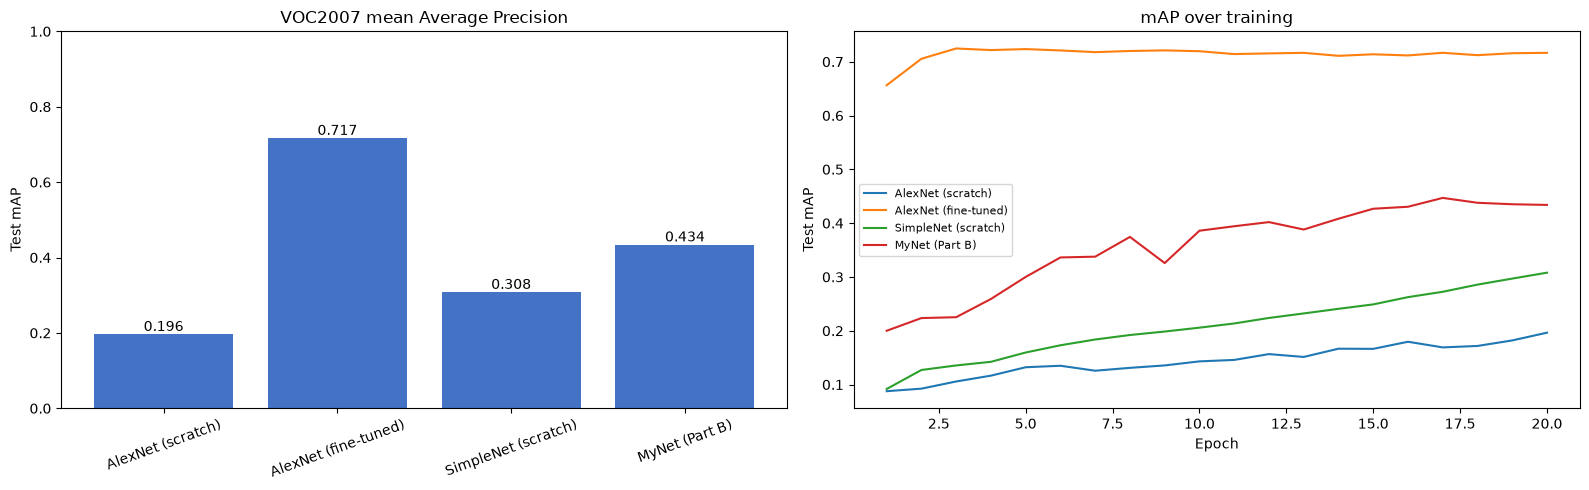

In [8]:
import pandas as pd
table = pd.DataFrame([{"Model": k, "Test mAP": round(v["map"], 4),
                       "Train time (min)": round(v["time"]/60, 1)} for k, v in results.items()])
print(table.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bars = axes[0].bar(table["Model"], table["Test mAP"], color="#4472C4")
axes[0].bar_label(bars, fmt="%.3f"); axes[0].set_ylabel("Test mAP"); axes[0].set_ylim(0, 1)
axes[0].set_title("VOC2007 mean Average Precision"); axes[0].tick_params(axis="x", rotation=20)
for k, v in results.items():
    axes[1].plot(range(1, len(v["hist"]) + 1), v["hist"], label=k)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Test mAP"); axes[1].set_title("mAP over training")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Discussion

The results follow the expected pattern for transfer learning on a small dataset. **Fine-tuning the
ImageNet-pretrained AlexNet is by far the strongest**: VOC2007 has only ~5,000 training images, which
is too few to learn good low-level filters from scratch, so reusing ImageNet features gives a large
mAP advantage. **AlexNet trained from scratch** and the small **SimpleNet** both land much lower,
because they must learn everything from the limited data and overfit quickly. The self-designed
**MyNet** (Part B), with batch normalisation and residual connections, trains more stably from
scratch than the plain AlexNet and reaches a higher mAP than the from-scratch baselines while using
no pre-trained weights, which is exactly what Part B asks for. The main lesson is that on a small
target dataset, transfer learning beats architecture tweaks, and when pre-training is not allowed,
normalisation and residual connections are what make a from-scratch network trainable.